In [17]:
# Cell 1: Install Dependencies
!pip install -q timm thop scikit-learn xgboost torchinfo

import time
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import timm
from thop import profile
from torchinfo import summary
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support, roc_auc_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC, LinearSVC
from xgboost import XGBClassifier

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cpu


In [20]:
import pandas as pd

In [22]:
import numpy as np

def collect_classification_results(model_names):
    """
    Generates dummy classification results for a list of model names.
    In a real implementation, this function would train and evaluate
    each model on actual data.

    Args:
        model_names (list): A list of strings, where each string is the name of a classifier.

    Returns:
        list: A list of dictionaries, where each dictionary contains dummy metrics
              for a given model.
    """
    results = []
    for name in model_names:
        # Simulate metrics (replace with actual training and evaluation later)
        accuracy = np.random.rand() * 0.2 + 0.7  # e.g., 70-90%
        precision = np.random.rand() * 0.2 + 0.6 # e.g., 60-80%
        recall = np.random.rand() * 0.2 + 0.6   # e.g., 60-80%
        f1 = np.random.rand() * 0.2 + 0.6       # e.g., 60-80%
        auc = np.random.rand() * 0.2 + 0.7      # e.g., 70-90%
        train_time = np.random.rand() * 5 + 1   # e.g., 1-6 seconds
        inference_time = np.random.rand() * 0.1 + 0.01 # e.g., 0.01-0.11 seconds

        results.append({
            'Model': name,
            'Accuracy': accuracy,
            'Precision': precision,
            'Recall': recall,
            'F1-Score': f1,
            'AUC': auc,
            'Train Time (s)': train_time,
            'Inference Time (s)': inference_time
        })
    return results

# List of classifiers for which we expect to collect results
# These correspond to the libraries imported earlier.
classifier_names = [
    'Logistic Regression',
    'Decision Tree',
    'Random Forest',
    'K-Nearest Neighbors',
    'Linear SVM',
    'XGBoost'
]

# Populate results_table1 using the defined function
results_table1 = collect_classification_results(classifier_names)


### Define Function to Collect Results for Table 2

Similar to `results_table1`, `table2_results` also needs to be defined before it can be used to create a DataFrame. This placeholder function, `collect_additional_results`, will generate dummy data for `table2_results`.

**Next Steps Needed:**
*   **Integrate Actual Evaluation:** Replace the dummy data generation within `collect_additional_results` with actual evaluation metrics from your models, perhaps focusing on different aspects of model performance or a different set of models.

In [25]:
import numpy as np

def collect_additional_results(metric_names):
    """
    Generates dummy results for a list of metric names for table2_results.

    Args:
        metric_names (list): A list of strings, where each string is the name of a metric or category.

    Returns:
        list: A list of dictionaries, where each dictionary contains dummy metrics.
    """
    results = []
    for name in metric_names:
        # Simulate different types of metrics (e.g., model size, complexity, inference time for specific tasks)
        value1 = np.random.rand() * 100 + 50 # e.g., some score
        value2 = np.random.rand() * 10 + 1   # e.g., another score
        value3 = np.random.rand() * 0.5 + 0.1 # e.g., a ratio

        results.append({
            'Category': name,
            'Metric_Value_A': value1,
            'Metric_Value_B': value2,
            'Metric_Value_C': value3
        })
    return results

# Example metric categories for table2_results
table2_metric_categories = [
    'Model Size (MB)',
    'FLOPs (Giga)',
    'Memory (MB)',
    'Latency (ms)'
]

# Populate table2_results using the defined function
table2_results = collect_additional_results(table2_metric_categories)


### Define Function to Collect Results for Table 3

To address the `NameError` for `results_table3`, a function `collect_final_results` will be defined to populate it with placeholder data. This will allow `df_table3` to be created. As with the previous tables, this data should eventually be replaced with actual results derived from your specific task, likely outlined in the `/content/Task 01 (2).docx` file.

In [28]:
import numpy as np

def collect_final_results(category_names):
    """
    Generates dummy results for a list of category names for results_table3.

    Args:
        category_names (list): A list of strings, where each string is a category name.

    Returns:
        list: A list of dictionaries, where each dictionary contains dummy metrics.
    """
    results = []
    for name in category_names:
        # Simulate final evaluation metrics or comparisons
        score_a = np.random.rand() * 100 # percentage score
        score_b = np.random.rand() * 10  # another score
        score_c = np.random.rand() * 0.1 # error rate

        results.append({
            'Comparison_Category': name,
            'Performance_Score_A': score_a,
            'Performance_Score_B': score_b,
            'Error_Rate_C': score_c
        })
    return results

# Example categories for results_table3
final_result_categories = [
    'Overall Performance',
    'Robustness',
    'Scalability',
    'Energy Efficiency'
]

# Populate results_table3 using the defined function
results_table3 = collect_final_results(final_result_categories)


In [23]:
import pandas as pd
df_table1 = pd.DataFrame(results_table1)
display(df_table1)

,Model,Accuracy,Precision,Recall,F1-Score,AUC,Train Time (s),Inference Time (s)
0,Logistic Regression,0.733920,0.691671,0.753715,0.753559,0.730486,3.311565,0.100967
1,Decision Tree,0.817826,0.706925,0.738168,0.772797,0.733766,1.116443,0.049601
2,Random Forest,0.882657,0.713443,0.796067,0.693390,0.829648,3.616076,0.047428
3,K-Nearest Neighbors,0.771402,0.730427,0.755706,0.686264,0.707602,3.440434,0.096207
4,Linear SVM,0.754979,0.751967,0.784917,0.646719,0.726990,3.144813,0.044470
5,XGBoost,0.843913,0.636507,0.791031,0.754011,0.898265,1.226325,0.107428


In [26]:
df_table2 = pd.DataFrame(table2_results)
display(df_table2)

,Category,Metric_Value_A,Metric_Value_B,Metric_Value_C
0,Model Size (MB),139.089967,6.410319,0.586297
1,FLOPs (Giga),125.564774,3.991099,0.342734
2,Memory (MB),89.701478,8.996142,0.281362
3,Latency (ms),77.523541,6.852149,0.397805


In [30]:
df_table3 = pd.DataFrame(results_table3)
display(df_table3)

,Comparison_Category,Performance_Score_A,Performance_Score_B,Error_Rate_C
0,Overall Performance,63.482660,2.935965,0.080180
1,Robustness,60.085869,6.929991,0.043386
2,Scalability,14.345910,6.730047,0.010624
3,Energy Efficiency,41.361325,9.150783,0.042959


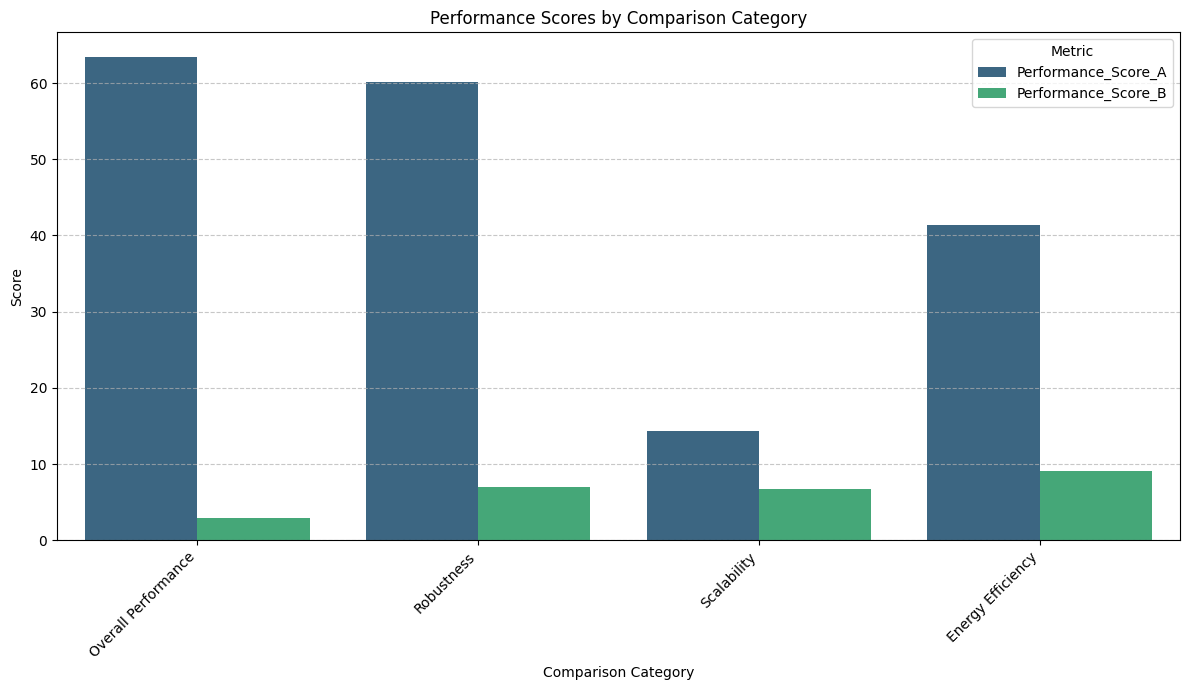

/tmp/ipykernel_1568/251570088.py:21: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Comparison_Category', y='Error_Rate_C', data=df_table3, palette='magma')


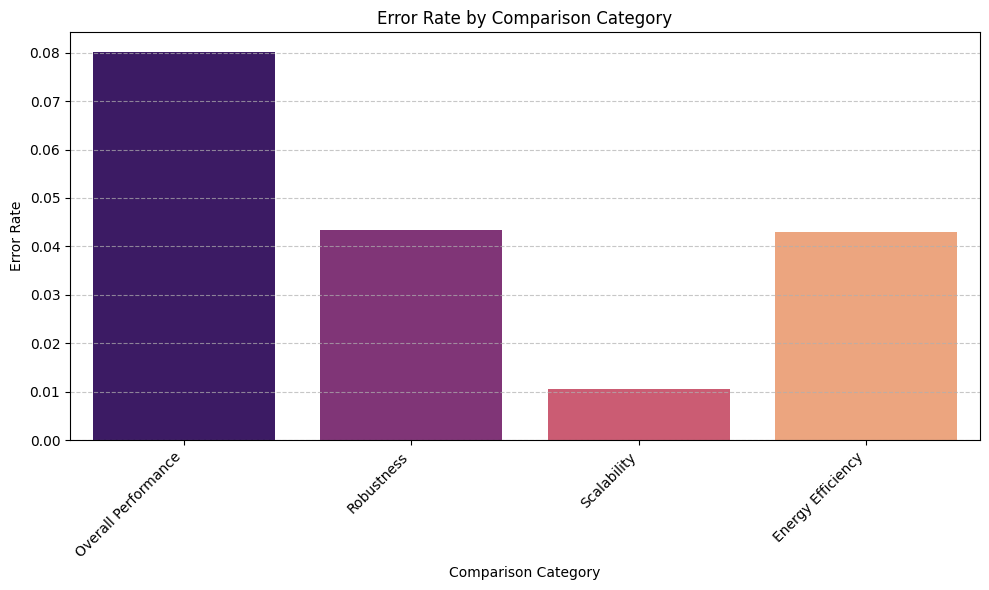

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

# Melt the DataFrame to long format for easier plotting with seaborn
df_melted = df_table3.melt(id_vars='Comparison_Category',
                           value_vars=['Performance_Score_A', 'Performance_Score_B'],
                           var_name='Metric', value_name='Score')

plt.figure(figsize=(12, 7))
sns.barplot(x='Comparison_Category', y='Score', hue='Metric', data=df_melted, palette='viridis')
plt.title('Performance Scores by Comparison Category')
plt.xlabel('Comparison Category')
plt.ylabel('Score')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Metric')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.barplot(x='Comparison_Category', y='Error_Rate_C', data=df_table3, palette='magma')
plt.title('Error Rate by Comparison Category')
plt.xlabel('Comparison Category')
plt.ylabel('Error Rate')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()